# Laboratório 05: Dados Ausentes - Tratamento Univariado e Multivariado
**Disciplina:** Extração e Preparação de Dados (IBM8915)
**Objetivo:** Aprender a usar ferramentas de descarte (`dropna`), preenchimento simples (`fillna`) com estatísticas básicas (univariado) e algoritmos de machine learning via Scikit-Learn (`KNNImputer`) (multivariado) para tratamento assertivo de dados defeituosos.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
import warnings
warnings.filterwarnings('ignore')

## Parte 1: Exemplo Guiado - A "Faca" e a "Seringa"
Neste exemplo rápido, usaremos o `.dropna()` (a faca) para amputar o que não tem salvação e o `.fillna()` (a seringa) para curar colunas numéricas e categóricas do nosso DataFrame de pacientes.

In [8]:
# Criando dados fictícios
df_exemplo = pd.DataFrame({
    'Paciente': ['Ana', 'Bruno', 'Carlos', 'Diana', 'Eduardo'],
    'Idade': [25, np.nan, 42, 38, np.nan],         # Numérica
    'Pressao': [120, 125, 130, np.nan, 140],       # Numérica
    'Tipo_Sanguineo': ['O+', 'A-', np.nan, 'O+', np.nan], # Categórica
    'Coluna_Perdida': [np.nan, np.nan, np.nan, np.nan, np.nan] # 100% Nula
})

print("Estado Original:\n", df_exemplo, "\n")

# 1. A Faca: Descartando colunas 100% vazias (axis=1 atinge colunas)
df_exemplo.dropna(axis=1, how='all', inplace=True)

# 2. A Seringa (Numéricos): Preenchendo Idade com a Mediana
mediana_idade = df_exemplo['Idade'].median()
df_exemplo['Idade'].fillna(mediana_idade, inplace=True)

# 3. A Seringa (Categóricos): Preenchendo Tipo Sanguíneo com a Moda
moda_sangue = df_exemplo['Tipo_Sanguineo'].mode()[0] #  pega a primeira moda se houver empate
df_exemplo['Tipo_Sanguineo'].fillna(moda_sangue, inplace=True)

print("Estado Tratado:\n", df_exemplo)

Estado Original:
   Paciente  Idade  Pressao Tipo_Sanguineo  Coluna_Perdida
0      Ana   25.0    120.0             O+             NaN
1    Bruno    NaN    125.0             A-             NaN
2   Carlos   42.0    130.0            NaN             NaN
3    Diana   38.0      NaN             O+             NaN
4  Eduardo    NaN    140.0            NaN             NaN 

Estado Tratado:
   Paciente  Idade  Pressao Tipo_Sanguineo
0      Ana   25.0    120.0             O+
1    Bruno   38.0    125.0             A-
2   Carlos   42.0    130.0             O+
3    Diana   38.0      NaN             O+
4  Eduardo   38.0    140.0             O+


## Parte 2: Exercício Prático (Mão na Massa)
Abaixo geramos um pequeno dataset de imóveis (`df_imoveis`). 
**Sua Tarefa:**
1. Descarte as colunas que possuam **mais de 70%** de valores nulos.
2. Preencha a coluna numérica `Preco` usando a estatística adequada (Média ou Mediana? Dica: Verifique se existem outliers absurdos com `.describe()`).
3. Preencha a coluna categórica `Bairro` com o valor mais comum (Moda).

In [9]:
# NÃO ALTERE ESTE CÓDIGO
np.random.seed(42)
df_imoveis = pd.DataFrame({
    'ID_Imovel': range(1, 101),
    'Bairro': np.random.choice(['Centro', 'Jardins', 'Vila Nova'], 100, p=[0.5, 0.3, 0.2]),
    'Preco': np.append(np.random.normal(300000, 50000, 95), [1500000, 2000000, 2500000, 3000000, 5000000]), # Com outliers milionários
    'Comissao_Corretor_Morta': [np.nan] * 100 # Coluna inútil
})

# Injetando nulos
df_imoveis.loc[np.random.choice(100, 15, replace=False), 'Preco'] = np.nan
df_imoveis.loc[np.random.choice(100, 20, replace=False), 'Bairro'] = np.nan

In [10]:
# ESCREVA SEU CÓDIGO AQUI
# Passo 1: Use dropna para derrubar a 'Comissao_Corretor_Morta'
print(df_imoveis.isnull().sum())
df_removendo = df_imoveis.dropna(subset=['Comissao_Corretor_Morta'])

# Passo 2: Decida entre .mean() e .median() para 'Preco' e faça o fillna
media = df_imoveis['Preco'].mean()
df_imoveis['Preco'].fillna(media, inplace=True)

# Passo 3: Use .mode() para preencher os bairros ausentes
preenchendo = df_imoveis['Bairro'].mode()

ID_Imovel                    0
Bairro                      20
Preco                       15
Comissao_Corretor_Morta    100
dtype: int64


---
## Parte 3: Tratamento Multivariado (Avançado com Scikit-Learn)
Em vez de olhar apenas para a coluna com valores ausentes (univariado), a imputação multivariada utiliza as **outras variáveis** da mesma linha para prever o valor faltante. Vamos usar o `KNNImputer`, que acha os exemplos mais "parecidos" (vizinhos) para inferir a lacuna.

In [11]:
from sklearn.impute import KNNImputer

# Criando um pequeno DataFrame de exemplo
df_knn = pd.DataFrame({
    'Salario': [5000, 5200, 9000, 5100, 8900],
    'Idade': [25, 27, 45, 26, np.nan],  # Alguém esqueceu a idade do último funcionário
    'Tempo_Empresa': [1, 2, 15, 1, 14]
})
print("Antes da Imputação (KNN):\n", df_knn, "\n")

# O KNNImputer substitui o valor ausente usando a média dos k vizinhos mais próximos
imputador_knn = KNNImputer(n_neighbors=2)
df_imputado_numpy = imputador_knn.fit_transform(df_knn)

# O Scikit-Learn retorna um array NumPy! Precisamos recriar o DataFrame
df_knn_tratado = pd.DataFrame(df_imputado_numpy, columns=df_knn.columns)
print("Após a Imputação (KNN):\n", df_knn_tratado)

Antes da Imputação (KNN):
    Salario  Idade  Tempo_Empresa
0     5000   25.0              1
1     5200   27.0              2
2     9000   45.0             15
3     5100   26.0              1
4     8900    NaN             14 

Após a Imputação (KNN):
    Salario  Idade  Tempo_Empresa
0   5000.0   25.0            1.0
1   5200.0   27.0            2.0
2   9000.0   45.0           15.0
3   5100.0   26.0            1.0
4   8900.0   36.0           14.0


### Exercício Prático: KNNImputer
Lembra da coluna `Preco` do nosso dataset `df_imoveis` (na Parte 2)? Se apenas preenchermos com a mediana global, ignoramos se a casa é uma mansão gigante ou um estúdio diminuto.
Vamos preencher o Preco agora de forma inteligente, usando a correlação com as variáveis numéricas fictícias adicionadas: `Metragem` e `Numero_Quartos`.

In [12]:
# NÃO ALTERE ESTE CÓDIGO - Gerando os novos dados correlacionados
np.random.seed(99)
df_imoveis_knn = pd.DataFrame({
    'Metragem': np.random.randint(40, 200, 100),
    'Numero_Quartos': np.random.randint(1, 4, 100)
})
# O preço verdadeiro será uma função clara da metragem e dos quartos
df_imoveis_knn['Preco'] = (df_imoveis_knn['Metragem'] * 5000) + (df_imoveis_knn['Numero_Quartos'] * 15000) + np.random.normal(0, 10000, 100)

# Injetando buracos apenas no Preco (deletando 20% das informações de preço da base)
df_imoveis_knn.loc[np.random.choice(100, 20, replace=False), 'Preco'] = np.nan
print("Amostra dos Dados Esburacados (Veja que as linhas com Preço nulo possuem Metragem):")
display(df_imoveis_knn.head(10))

Amostra dos Dados Esburacados (Veja que as linhas com Preço nulo possuem Metragem):


,Metragem,Numero_Quartos,Preco
0,169,1,860924.376600
1,75,3,424236.639812
2,108,3,577930.635590
3,169,1,866467.247276
4,191,3,NaN
5,75,2,414582.437580
6,95,2,NaN
7,99,3,536799.101598
8,147,3,781155.630139
9,170,3,893615.619650


In [ ]:
from sklearn.impute import KNNImputer

# Passo 1: Instancie o KNNImputer (vamos usar 5 vizinhos para maior precisão)
imputer = KNNImputer(n_neighbors=5)

# Passo 2: Aplique o fit_transform no df_imoveis_knn e guarde o resultado
imoveis_numpy = imputer.fit_transform(df_imoveis_knn)

# Passo 3: Recrie o Pandas DataFrame com os nomes originais das colunas
df_imoveis_final = pd.DataFrame(imoveis_numpy, columns=df_imoveis_knn.columns)

# Passo 4: Exiba o novo dataset tratado para validar se os preços foram preenchidos
display(df_imoveis_final.head(10))

# Validação extra: verificando se ainda restam nulos
print("\nSoma de valores nulos após KNN:")
print(df_imoveis_final.isna().sum())

---
## Parte 4: Desafio para Casa - O Pipeline do Engenheiro de Dados
Este desafio consolida as **Aulas 02 a 07**. Rode a célula abaixo para gerar um arquivo CSV no seu disco chamado `ecommerce_messy.csv`.

**A Missão:**
1. **(Aula 02):** Carregue o arquivo lidando com o separador `;` e o encoding `latin-1`.
2. **(Aula 05):** Audite e remova as linhas inteiramente duplicadas.
3. **(Aula 04):** Converta a coluna `Categoria` para o tipo `category` para salvar memória.
4. **(Aula 06):** Plote um `sns.heatmap` para ver onde estão os nulos.
5. **(Aula 07):** Faça a imputação: `Idade` (Numérica) e `Categoria` (Texto).
6. **(Aula 04):** Calcule o Ticket Médio (`Renda`) agrupado por `Categoria`.

In [11]:
# NÃO ALTERE ESTE CÓDIGO - Geração de dados sujos reais no disco
np.random.seed(10)
n = 800
df_desafio = pd.DataFrame({
    'ID_Cliente': np.random.randint(1000, 9999, n),
    'Idade': np.random.normal(35, 10, n),
    'Renda': np.random.normal(5000, 2000, n),
    'Categoria': np.random.choice(['Eletrônicos', 'Móveis', 'Vestuário'], n)
})

# Inserindo buracos (NaNs)
df_desafio.loc[np.random.choice(n, 120, replace=False), 'Idade'] = np.nan
df_desafio.loc[np.random.choice(n, 60, replace=False), 'Categoria'] = np.nan

# Inserindo linhas duplicadas
df_desafio = pd.concat([df_desafio, df_desafio.sample(45)], ignore_index=True)

# Exportando para o formato legado "Brasileiro"
df_desafio.to_csv('ecommerce_messy.csv', sep=';', encoding='latin-1', index=False)
print("Arquivo 'ecommerce_messy.csv' gerado na sua pasta local!")

Arquivo 'ecommerce_messy.csv' gerado na sua pasta local!


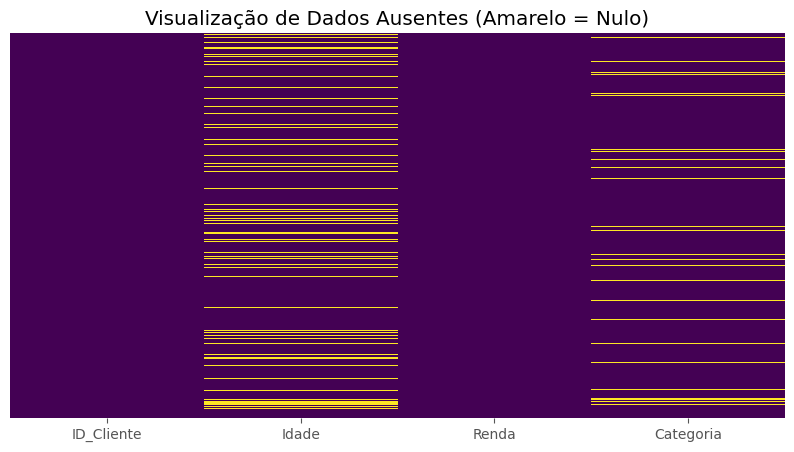

--- Resumo por Categoria ---
                 Idade        Renda  Total_Clientes
Categoria                                          
Eletrônicos  35.419131  4896.284120             240
Móveis       34.493795  4968.082803             326
Vestuário    34.802260  4887.134394             234

Quantidade de nulos após o tratamento:
ID_Cliente    0
Idade         0
Renda         0
Categoria     0
dtype: int64


In [12]:
# --- INÍCIO DO SEU CÓDIGO ---

# 1. Carregue o CSV (read_csv com sep e encoding corretos)
df = pd.read_csv('ecommerce_messy.csv', sep=';', encoding='latin-1')

# 2. Remova duplicatas (.drop_duplicates)
# O dataset original tinha 45 linhas duplicadas adicionadas propositalmente.
df = df.drop_duplicates()

# 3. Otimização de tipo (.astype('category'))
# A coluna 'Categoria' é ideal para o tipo category pois tem poucos valores únicos.
df['Categoria'] = df['Categoria'].astype('category')

# 4. Heatmap do Seaborn (sns.heatmap)
# Visualizando onde estão os "buracos" (nulos) nos dados.
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Visualização de Dados Ausentes (Amarelo = Nulo)")
plt.show()

# 5. Tratamento Univariado (fillna com mediana/moda)
# Idade: Usamos a mediana para evitar distorções por valores extremos.
mediana_idade = df['Idade'].median()
df['Idade'] = df['Idade'].fillna(mediana_idade)

# Categoria: Usamos a moda (valor mais frequente) por ser um dado textual/categórico.
moda_cat = df['Categoria'].mode()[0]
df['Categoria'] = df['Categoria'].fillna(moda_cat)

# 6. Análise Agrupada (groupby)
# Vamos verificar a média de Renda e Idade por Categoria após o tratamento.
analise_final = df.groupby('Categoria').agg({
    'Idade': 'mean',
    'Renda': 'mean',
    'ID_Cliente': 'count'
}).rename(columns={'ID_Cliente': 'Total_Clientes'})

print("--- Resumo por Categoria ---")
print(analise_final)

# Validação final de nulos
print("\nQuantidade de nulos após o tratamento:")
print(df.isna().sum())

---
## Parte 5: Desafio Final - Sobreviventes do Titanic (KNNImputer)
Para fixar o conhecimento de imputação multivariada vamos usar o famoso dataset do Titanic, embutido na biblioteca Seaborn.
O problema crônico desse dataset é a coluna `age` (idade), que possui dezenas de valores nulos. Usar apenas a média geral distorce a realidade: passageiros da 1ª classe tendiam a ser mais velhos que os da 3ª classe, e pessoas que viajavam sozinhas tinham idades diferentes das que viajavam em grandes famílias.

**Sua Missão:**
1. Isolar um sub-dataset apenas com características numéricas relevantes: `survived`, `pclass`, `age`, `sibsp` (Irmãos/Cônjuges), `parch` (Pais/Filhos) e `fare` (Tarifa).
2. Instanciar o `KNNImputer` e treinar neste sub-dataset para preencher as idades.
3. Recriar o DataFrame e confirmar que não existem mais nulos na variável `age` usando `.info()` ou `.isna().sum()`.

In [14]:
# Carregando os dados originais do Titanic
df_titanic = sns.load_dataset('titanic')

print("Quantidade de Nulos Originais:")
display(df_titanic.isna().sum())

print("\nAmostra dos dados (note as idades NaN):")
display(df_titanic[df_titanic['age'].isna()].head())

Quantidade de Nulos Originais:


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


Amostra dos dados (note as idades NaN):


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
17,1,2,male,NaN,0,0,13.0000,S,Second,man,True,NaN,Southampton,yes,True
19,1,3,female,NaN,0,0,7.2250,C,Third,woman,False,NaN,Cherbourg,yes,True
26,0,3,male,NaN,0,0,7.2250,C,Third,man,True,NaN,Cherbourg,no,True
28,1,3,female,NaN,0,0,7.8792,Q,Third,woman,False,NaN,Queenstown,yes,True


In [15]:
from sklearn.impute import KNNImputer

# Passo 1: Selecionando apenas as colunas numéricas especificadas
df_titanic_num = df_titanic[['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']]

# Passo 2: Instanciando o KNNImputer (5 vizinhos é o padrão comum)
imputer = KNNImputer(n_neighbors=5)

# Passo 3: Aplicando o fit_transform
# Importante: o resultado é uma matriz (array) do NumPy
df_imputado_array = imputer.fit_transform(df_titanic_num)

# Passo 4: Convertendo a matriz de volta para um DataFrame do Pandas
# Mantendo os nomes das colunas originais
df_titanic_final = pd.DataFrame(df_imputado_array, columns=df_titanic_num.columns)

# Passo 5: Exibindo a quantidade de nulos para validar o sucesso
print("--- Verificação de Nulos Após KNNImputer ---")
print(df_titanic_final.isna().sum())

# Opcional: Comparar as primeiras linhas para ver a idade preenchida
print("\nPrimeiras linhas do DataFrame tratado:")
display(df_titanic_final.head())



--- Verificação de Nulos Após KNNImputer ---
survived    0
pclass      0
age         0
sibsp       0
parch       0
fare        0
dtype: int64

Primeiras linhas do DataFrame tratado:


,survived,pclass,age,sibsp,parch,fare
0,0.0,3.0,22.0,1.0,0.0,7.2500
1,1.0,1.0,38.0,1.0,0.0,71.2833
2,1.0,3.0,26.0,0.0,0.0,7.9250
3,1.0,1.0,35.0,1.0,0.0,53.1000
4,0.0,3.0,35.0,0.0,0.0,8.0500
